# 📝 Proyecto: Prediciendo la Diabetes con Boosting

En los dos proyectos anteriores, exploramos cómo utilizar un **Árbol de Decisión** y un **Random Forest** para predecir la diabetes. Sin embargo, siempre hay margen de mejora. ¿Será el **Boosting** la clave para optimizar nuestros resultados?

El **Boosting** es una técnica de aprendizaje de conjunto (ensemble) que construye modelos (generalmente árboles de decisión) de forma **secuencial**. Cada nuevo modelo intenta corregir los errores cometidos por el anterior. Dado que nuestro conjunto de datos cumple con varias suposiciones estudiadas, este enfoque podría elevar significativamente nuestro **accuracy**.

---

## 🚀 Paso 1: Carga del conjunto de datos
Carga el conjunto de datos procesado del proyecto anterior. Asegúrate de que incluya:
* Muestras de entrenamiento y prueba ($X_{train}, X_{test}, y_{train}, y_{test}$).
* El preprocesamiento y análisis derivado del EDA previo.

## 🧠 Paso 2: Construye un modelo de Boosting
Para optimizar los resultados, generaremos un modelo de Boosting (como **XGBoost**, **Gradient Boosting** o **AdaBoost**).
1.  **Entrenamiento:** Ajusta el modelo con los datos de entrenamiento.
2.  **Optimización:** Prueba modificando hiperparámetros (n_estimators, learning_rate, max_depth, etc.).
3.  **Visualización:** Analiza el impacto de los cambios en la precisión final y grafica las conclusiones (curvas de aprendizaje o importancia de variables).

## 💾 Paso 3: Guarda el modelo
Almacena el modelo final entrenado en la carpeta correspondiente para asegurar su persistencia.

## 📊 Paso 4: Analiza y compara resultados
Realiza un estudio comparativo de los tres modelos utilizados hasta ahora:
1.  Árbol de Decisión.
2.  Random Forest.
3.  Boosting.

**Preguntas de reflexión:**
* ¿Qué clase tiene mayor precisión de predicción?
* ¿Cuál presenta más errores?
* ¿Con cuál de los tres modelos te quedarías para producción y por qué?

In [1]:
import os
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV, StratifiedKFold)
from sklearn.metrics import ( confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_recall_curve)

from scipy.stats import randint, uniform, loguniform


In [2]:
# Cargamos el dataset que como recordaremos en el ejericio anterior es el que tiene outliers suavizados lo hacemos a traves de paquete pk1
model_pack = joblib.load('../data/processed/models/diabetes04/diabetes_rf_rt.pkl')
# Creamos nuestras variales y les asignamos los valores del paquete, model_dt y model_rf son los modelos de los ejercicio anteriores.
model_dt, model_rf, x_train, x_test, y_train, y_test = model_pack["model_dt"], model_pack["model_rf"], model_pack["x_train"], model_pack["x_test"], model_pack["y_train"], model_pack["y_test"]
x_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
60,2.0,84.0,72.0,29.0,125.000,32.3,0.304000,21
618,9.0,112.0,82.0,24.0,125.000,28.2,1.172125,50
346,1.0,139.0,46.0,19.0,95.375,28.7,0.654000,22
294,0.0,161.0,50.0,29.0,125.000,21.9,0.254000,64
231,6.0,134.0,80.0,37.0,150.375,46.2,0.238000,46
...,...,...,...,...,...,...,...,...
71,5.0,139.0,64.0,35.0,140.000,28.6,0.411000,26
106,1.0,96.0,104.0,29.0,125.000,22.4,0.207000,27
270,10.0,101.0,86.0,37.0,125.000,45.6,1.136000,38
435,0.0,141.0,72.0,29.0,125.000,42.4,0.205000,29


In [3]:
#Repetimos el codigo del anterior ejercicio para darnos una pista de que parametros podrian servirnos en este caso vamos a incluir a n_estimators y max_depth
# a la lista de opciones en el GridSearchCV
columns = ["n_estimators", "max_depth", "criterion", "class_weight", "min_samples_leaf", "min_samples_split", "max_features"]
parameters_result = pd.DataFrame([model_rf.get_params()])
parameters_result[columns]

,n_estimators,max_depth,criterion,class_weight,min_samples_leaf,min_samples_split,max_features
0,100,5,entropy,"{0: 1, 1: 1}",5,12,sqrt


In [4]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

base_model = LGBMClassifier(
    objective="binary",
    random_state=42,
    verbose=-1,
    n_jobs=-1
)

random_space = {
    "max_depth": randint(1, 7),
    "learning_rate": loguniform(0.001, 0.1),
    "n_estimators": randint(30, 200),
    "scale_pos_weight": randint(1, 6),
}

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=random_space,
    n_iter=500,
    scoring="precision",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(x_train, y_train)
best = random_search.best_estimator_


Fitting 10 folds for each of 500 candidates, totalling 5000 fits


In [13]:
columns = ["max_depth", "learning_rate", "n_estimators", "scale_pos_weight"]
parameters_result = pd.DataFrame([best.get_params()])
parameters_result[columns]

,max_depth,learning_rate,n_estimators,scale_pos_weight
0,6,0.002042,154,2


In [14]:
def range_params(param, steps = 2,  step_size=1):
    param_list = []
    decimals = max(0, -int(round(np.log10(step_size))))
    for i in range(steps, 0, -1):
        if (i != 0):
            param_list.append(round(param - i*step_size, decimals))
    param_list.append(param)
    for i in range(1, steps+1):
        param_list.append(round(param + i*step_size, decimals))
    return param_list

grid_structure = {
    "max_depth": range_params(parameters_result["max_depth"][0], 1),
    "learning_rate": range_params(parameters_result["learning_rate"][0], 2, 0.0002),
    "n_estimators": range_params(parameters_result["n_estimators"][0], 2, 2),
    "scale_pos_weight": range_params(parameters_result["scale_pos_weight"][0], 1),
}
# grid_structure = {
#     "max_depth": [5,6,7],
#     "learning_rate": [0.0017,0.0018,0.002042,0.00228,0.00238],
#     "n_estimators": [150 ,152, 154, 156, 158],
#     "scale_pos_weight": [1 ,2, 3],
# }

search_structure = GridSearchCV(
    estimator=base_model,
    param_grid=grid_structure,
    scoring="precision",
    cv=cv,
    n_jobs=-1,
    verbose=1
)
search_structure.fit(x_train, y_train)
best = search_structure.best_estimator_


Fitting 10 folds for each of 225 candidates, totalling 2250 fits


In [ ]:
columns = ["max_depth", "learning_rate", "n_estimators", "scale_pos_weight"]
parameters_result = pd.DataFrame([best.get_params()])
parameters_result[columns]

,max_depth,learning_rate,n_estimators,scale_pos_weight
0,5,0.002042,150,2


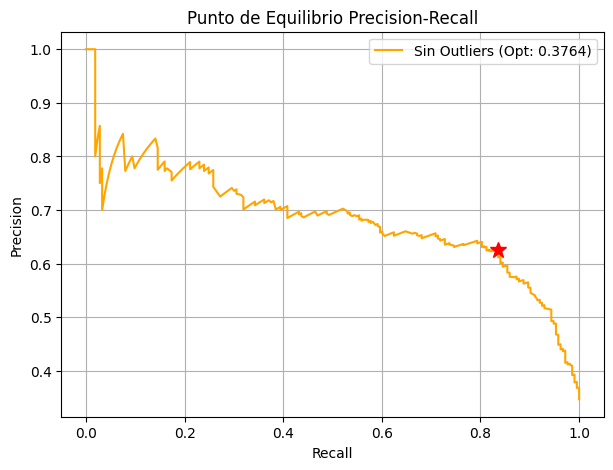

El umbral sugerido es: 0.3764


In [15]:
#Hacemos los mismo que el ejericio anterior y graficamos cual seria el umbral mas equilibrado para el modelo de ramdomforest
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_preds = np.zeros(len(x_train))  # out-of-fold predictions

for train_idx, val_idx in kf.split(x_train, y_train):
    X_tr, X_val = x_train.iloc[train_idx], x_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    best.fit(X_tr, y_tr)
    # Predicción SOLO en el fold de validación
    oof_preds[val_idx] = best.predict_proba(X_val)[:, 1]
    

p, r, t = precision_recall_curve(y_train, oof_preds)

f1_scores = 2 * (p * r) / (p + r + 1e-10) 
idx_f1 = np.argmax(f1_scores)

umbral = t[idx_f1]


plt.figure(figsize=(7, 5))
plt.plot(r, p, label=f'Sin Outliers (Opt: {umbral:.4f})', color = 'orange')
plt.plot(r[idx_f1], p[idx_f1], 'r*', markersize = 12) # Estrella en el punto

plt.title('Punto de Equilibrio Precision-Recall')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.legend(); plt.grid(True); plt.show()

print(f"El umbral sugerido es: {umbral:.4f}")

In [16]:
#Tambien cargamos el modelo anterior para comparar
best.fit(x_train, y_train)
predictions_boost = best.predict_proba(x_test)[:, 1]
predictions_boost = (predictions_boost >= umbral).astype(int)
metrics_boost = classification_report(y_test, predictions_boost, output_dict = True)
print(classification_report(y_test, predictions_boost))

              precision    recall  f1-score   support

           0       0.88      0.64      0.74        99
           1       0.56      0.84      0.67        55

    accuracy                           0.71       154
   macro avg       0.72      0.74      0.70       154
weighted avg       0.76      0.71      0.71       154



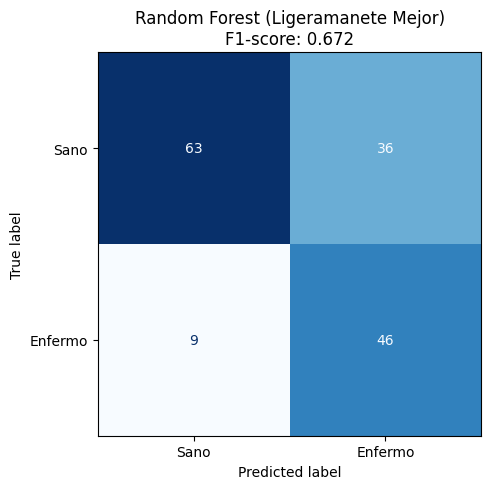

In [17]:
# Vamos ahora a comparar ambas predicciones con una matriz de confucion
fig, (ax1) = plt.subplots(1, 1, figsize=(12, 5))

# Random Forest (Ahora)
cm_boost = confusion_matrix(y_test, predictions_boost)
disp_boost = ConfusionMatrixDisplay(confusion_matrix=cm_boost, display_labels=["Sano", "Enfermo"])
disp_boost.plot(ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title(f"Random Forest (Ligeramanete Mejor)\nF1-score: {metrics_boost['1']['f1-score']:.3f}")

plt.tight_layout()
plt.show()